## Library Imports

In [1]:
# install csep python library
#!pip install cartopy
#!pip install pyCSEP
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import cartopy
import csep
from csep.utils import datasets, time_utils, plots
from csep.core import poisson_evaluations as poisson
from scipy.stats import poisson as poisson_stat

import sys
import os
sys.path.append(os.path.abspath("../src"))
# import functions for hdf5 forecast format
import functions_for_hdf5_parallel as f_hdf5
# import functions to calculate the Q and L-Scores
import QandL as QL

Catalog of observed events used in Section 4 can be obtained for any time frame depending on the year/month/day hour\:minute\:second. On the paper we only focused on a time frame of a calendar year. Model forecasts can be obtained depending on the day/month/year. This can only be done depending on the date that the model was run. For start and end dates, please refer to: https://cseptesting.org/grid-based-forecasts/ Model's forecast can also be dowloaded from there.

NOTE: Forecast data has to be downloaded before running the following code. Files are in hdf5 format.

## 2008

Fetched ComCat catalog in 2.6958236694335938 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2008-01-02 03:48:12.500000+00:00
End Date: 2008-12-31 22:56:00.220000+00:00
Min Latitude: 31.5038333 and Max Latitude: 42.0371667
Min Longitude: -125.3458333 and Max Longitude: -113.1393333
Min Magnitude: 2.5
Found 1703 events in the ComCat catalog.

        Name: None

        Start Date: 2008-01-19 17:18:46.470000+00:00
        End Date: 2008-12-28 05:17:07.470000+00:00

        Latitude: (31.8333333, 41.1885)
        Longitude: (-125.3406667, -115.2295)

        Min Mw: 3.95
        Max Mw: 5.44

        Event Count: 55
        


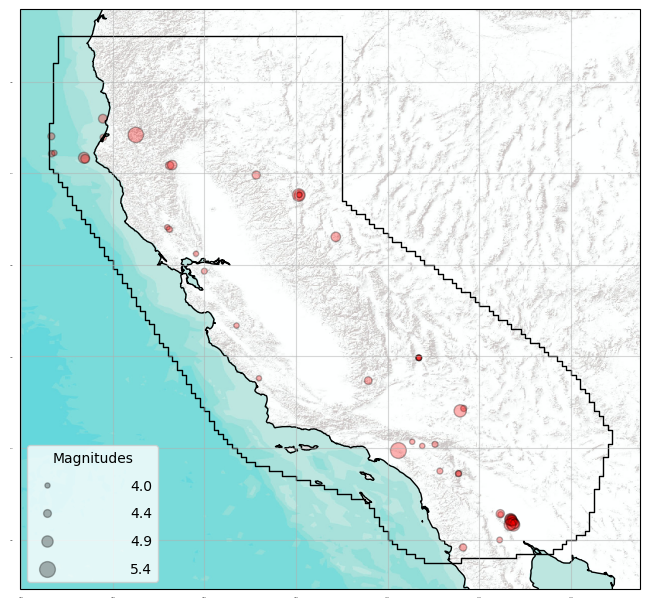

<GeoAxes: >

In [2]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2008-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2008-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)

# Plot of the location of observed events proportional to their magnitude
catalog.plot(show=True)

### ETAS

In [3]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2008', # format dd/mm/yyyy
                                     end_date = '31/12/2008')

Loading year: 2008
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [4]:
len(catalogEvents)

55

#### Q-Score

In [5]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

3
[3.6461699437495554e-07, 9.023690239473581e-08, 7.213860158117313e-07]
[34, 25, 2]
4.009537e-07
0.97786845617939


In [4]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
#Here we are retaining the top 5% of observed magnitudes
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.47329792


#### L-Score

In [5]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))

# Optional to free memory space
del ETAS_forec

-330.7752


### STEP

In [6]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder****
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2008', # format dd/mm/yyyy
                                     end_date = '31/12/2008')

Loading year: 2008
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [7]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

3
[2.1552786222400755e-07, 1.2166989904471848e-07, 5.495485311257653e-06]
[34, 25, 2]
2.8474489e-07
6.827963521740129


In [7]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
#Here we are retaining the top 5% of observed magnitudes
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.4931226


#### L-Score

In [8]:
print(QL.ell_score(fore_df= STEP_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del STEP_forec

-211.03438


## 2009

Fetched ComCat catalog in 2.0632810592651367 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2009-01-01 03:37:59.850000+00:00
End Date: 2009-12-31 19:57:42.940000+00:00
Min Latitude: 31.5523333 and Max Latitude: 42.5413333
Min Longitude: -125.398 and Max Longitude: -113.1813333
Min Magnitude: 2.5
Found 1207 events in the ComCat catalog.

        Name: None

        Start Date: 2009-01-04 17:27:10.480000+00:00
        End Date: 2009-12-30 19:07:41.530000+00:00

        Latitude: (31.711, 42.5413333)
        Longitude: (-124.637, -114.539)

        Min Mw: 3.95
        Max Mw: 5.8

        Event Count: 43
        


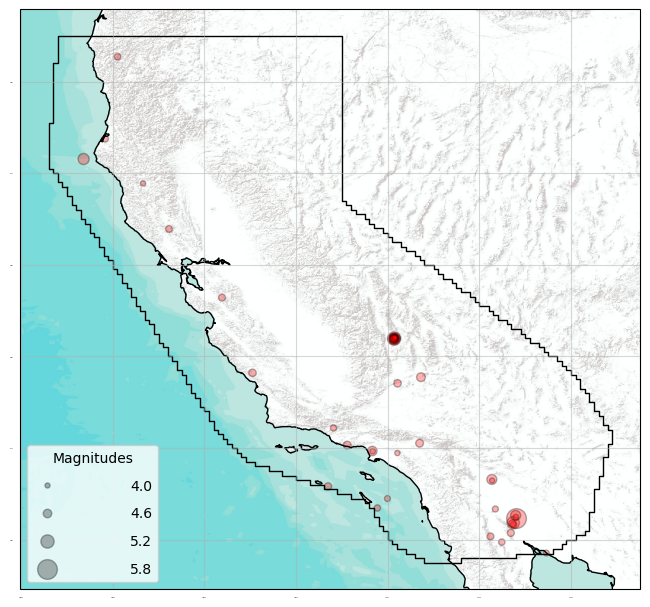

<GeoAxes: >

In [8]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2009-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2009-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)

# Plot of the location of observed events proportional to their magnitude
catalog.plot(show=True)

### ETAS

In [9]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2009', # format dd/mm/yyyy
                                     end_date = '31/12/2009')

Loading year: 2009
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [10]:
len(catalogEvents)

43

#### Q-Score

In [11]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

3
[3.095640010997158e-07, 8.273170351458248e-06, 1.0310300240234938e-06]
[40, 27, 22]
3.848926e-07
8.325928408699204


In [11]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.6609501


#### L-Score

In [12]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))
#Optional to free memory space
del ETAS_forec

-276.55215


### STEP

In [12]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2009', # format dd/mm/yyyy
                                     end_date = '31/12/2009')

Loading year: 2009
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [13]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

3
[1.3625665360450512e-06, 0.0006341634434647858, 3.3597511901461985e-06]
[40, 27, 22]
2.5492423e-07
835.3930087902701


In [14]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.9303938


#### L-Score

In [15]:
print(QL.ell_score(fore_df= STEP_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del STEP_forec

-165.31847


### KJSSOneDay

In [14]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2009', # format dd/mm/yyy
                                     end_date = '31/12/2009')

Loading year: 2009
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [15]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

3
[2.838787338532711e-08, 3.753110649995506e-05, 1.1036933074137778e-06]
[40, 27, 22]
2.9296926e-08
439.90039522326936


In [17]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.584117


#### L-Score

In [19]:
#L-score diverges
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents, 
                    waterlevel = 1e-6))

#Optional to free memory space
del KJSSOne_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf
-224.68491759829112


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


## 2010

Fetched ComCat catalog in 3.734419107437134 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2010-01-01 02:33:42.820000+00:00
End Date: 2010-12-31 17:59:32.590000+00:00
Min Latitude: 31.5136667 and Max Latitude: 42.4743333
Min Longitude: -125.399 and Max Longitude: -113.1186667
Min Magnitude: 2.5
Found 4998 events in the ComCat catalog.

        Name: None

        Start Date: 2010-01-04 14:24:54.440000+00:00
        End Date: 2010-12-23 12:37:35.020000+00:00

        Latitude: (31.715, 40.9511667)
        Longitude: (-125.2775, -114.8613333)

        Min Mw: 3.95
        Max Mw: 7.2

        Event Count: 187
        


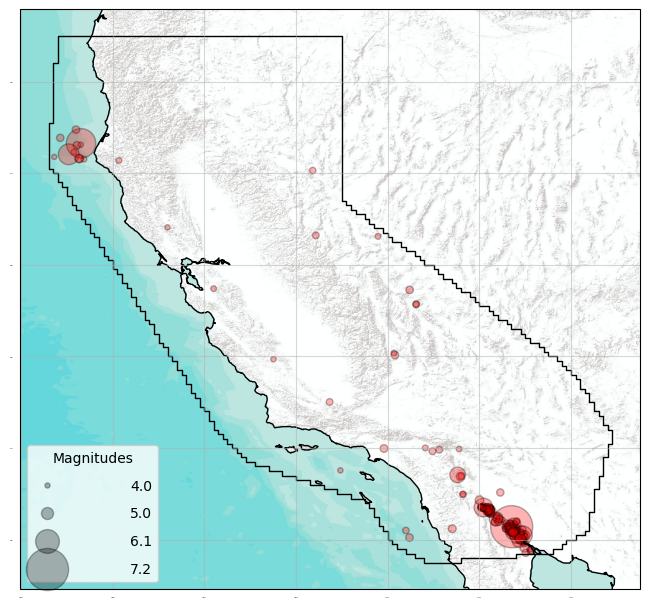

<GeoAxes: >

In [16]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2010-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2010-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [17]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2010', # format dd/mm/yyyy
                                     end_date = '31/12/2010')

Loading year: 2010
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [18]:
len(catalogEvents)

187

#### Q-Score

In [19]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

10
[2.884439993522392e-07, 9.239069953537182e-08, 1.1388599432393676e-06, 1.8744799490377773e-06, 6.656539881078061e-06, 1.6448400856461376e-05, 8.507889788234024e-07, 1.6448400856461376e-05, 0.00016647999291308224, 1.0038799700851087e-05]
[24, 2, 12, 147, 26, 29, 158, 33, 95, 25]
9.493882e-07
23.206218036406106


In [22]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.0597266


#### L-Score

In [23]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-667.6469


### STEP 

In [20]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2010', # format dd/mm/yyyy
                                     end_date = '31/12/2010')

Loading year: 2010
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [21]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

10
[4.7006441405983423e-08, 4.562757283110841e-07, 1.306333672346227e-07, 4.24578320235014e-06, 1.0407273265400363e-07, 2.04247794499679e-06, 2.676885060282075e-07, 2.04247794499679e-06, 0.0009355677175335586, 2.858327547983208e-07]
[24, 2, 12, 147, 26, 29, 158, 33, 95, 25]
1.0345215e-06
91.3649452668162


In [25]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

4.006758


#### L-Score

In [26]:
print(QL.ell_score(fore_df= STEP_forec,
                        cat_df = catalogEvents))
#Optional to free memory space
del STEP_forec

-468.13376


### KJSSOneDay

In [22]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2010', # format dd/mm/yyy
                                     end_date = '31/12/2010')

Loading year: 2010
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [23]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

10
[5.4801681415028725e-08, 3.914905621904552e-10, 1.1288496182260133e-07, 1.1902409369213274e-06, 1.2133976490247278e-08, 3.013129116880009e-06, 1.8423884284857195e-06, 3.013129116880009e-06, 0.00011528968752827495, 4.0030583292605115e-09]
[24, 2, 12, 147, 26, 29, 158, 33, 95, 25]
1.2078172e-07
103.1056600714347


In [28]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.1648054


#### L-Score

In [29]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-634.06274


## 2011

Fetched ComCat catalog in 2.7460198402404785 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2011-01-01 00:34:10.130000+00:00
End Date: 2011-12-31 19:14:44.380000+00:00
Min Latitude: 31.5168333 and Max Latitude: 42.6163333
Min Longitude: -125.3978333 and Max Longitude: -113.1328333
Min Magnitude: 2.5
Found 1386 events in the ComCat catalog.

        Name: None

        Start Date: 2011-01-08 00:10:16.740000+00:00
        End Date: 2011-12-30 15:34:29.360000+00:00

        Latitude: (31.8105, 41.027)
        Longitude: (-125.363, -114.6905)

        Min Mw: 3.95
        Max Mw: 5.09

        Event Count: 48
        


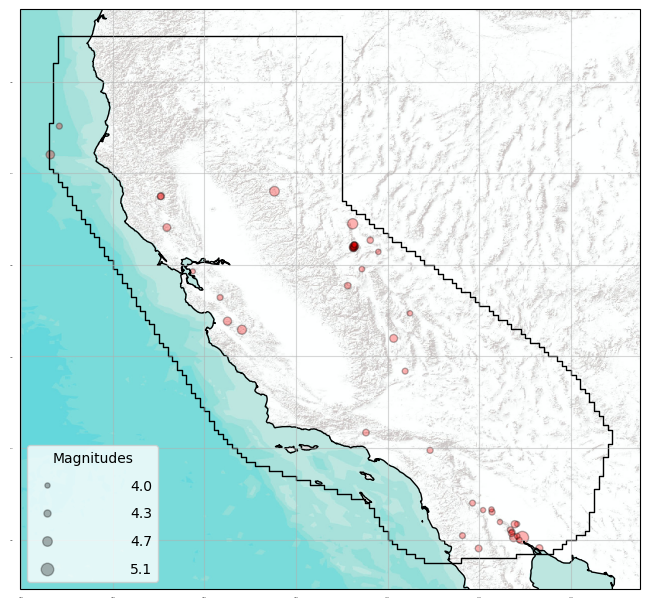

<GeoAxes: >

In [24]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2011-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2011-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [25]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2011', # format dd/mm/yyyy
                                     end_date = '31/12/2011')

Loading year: 2011
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [26]:
len(catalogEvents)

48

#### Q-Score

In [27]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

3
[4.028579951409483e-06, 5.19522018294083e-07, 4.222929987918178e-07]
[6, 40, 45]
4.1579867e-07
3.984616728920526


In [32]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.9381611


#### L-Score

In [33]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-295.47137


### STEP

In [28]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2011', # format dd/mm/yyyy
                                     end_date = '31/12/2011')

Loading year: 2011
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [29]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

3
[1.5212948710541241e-05, 1.3102345874926868e-08, 1.1517188092113884e-08]
[6, 40, 45]
3.220016e-07
15.773801940968049


In [35]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.7694991


#### L-Score

In [36]:
print(QL.ell_score(fore_df= STEP_forec,
                        cat_df = catalogEvents))
#Optional to free memory space
del STEP_forec

-210.34457


### STEPJAVA

In [30]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2011', # format dd/mm/yyy
                                     end_date = '31/12/2011')

Loading year: 2011
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [31]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

3
[8.055206308199558e-06, 4.70261198870503e-07, 1.1517188092113884e-08]
[6, 40, 45]
2.5260573e-07
11.265229667602934


In [42]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEPJAVA
del all_df
#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.9638286


#### L-Score

In [43]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-254.19117290238606


### KJSSOneDay

In [32]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2011', # format dd/mm/yyy
                                     end_date = '31/12/2011')

Loading year: 2011
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [33]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

3
[2.1086077595100505e-06, 2.8622562653346506e-11, 9.222431152089428e-11]
[6, 40, 45]
3.511712e-08
20.016148885037115


In [45]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.82929504


#### L-Score

In [46]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-248.3789


## 2012

Fetched ComCat catalog in 2.183828115463257 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2012-01-02 07:02:46.080000+00:00
End Date: 2012-12-30 12:25:45.570000+00:00
Min Latitude: 31.5135 and Max Latitude: 42.8158333
Min Longitude: -125.3935 and Max Longitude: -113.126
Min Magnitude: 2.5
Found 1193 events in the ComCat catalog.

        Name: None

        Start Date: 2012-01-17 09:55:00.520000+00:00
        End Date: 2012-12-22 21:37:45.140000+00:00

        Latitude: (31.8735, 41.1431667)
        Longitude: (-125.3308333, -114.9953333)

        Min Mw: 3.95
        Max Mw: 5.6

        Event Count: 50
        


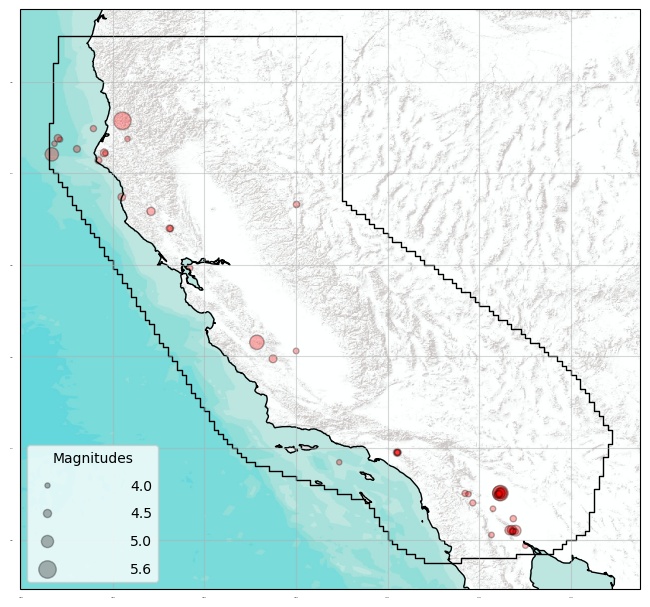

<GeoAxes: >

In [34]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2012-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2012-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [35]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2012', # format dd/mm/yyyy
                                     end_date = '31/12/2012')

Loading year: 2012
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [36]:
len(catalogEvents)

50

In [37]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

3
[6.80160994193102e-08, 2.9712600735365413e-07, 3.734830045232229e-07]
[3, 32, 29]
4.3073334e-07
0.5716027743476852


In [44]:
#Initialize an empty list to store data

all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.3083407


#### L-Score

In [50]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents,))

#Optional to free memory space
del ETAS_forec

-295.56293


### STEP

In [38]:
## Load STEP model
## start date: 01 Aug. 2007    end date: 21 Jan. 2013
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
step_filename = '../data/STEP_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEP = f_hdf5.load_hdf5_to_dict(step_filename,
                                     start_date = '01/01/2012', # format dd/mm/yyyy
                                     end_date = '31/12/2012')

Loading year: 2012
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [39]:
STEPforecast = QL.combine_forecast_dataframes(STEP)
del STEP

QSTEP = QL.q_score_calc(
    forecast_df=STEPforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEP)

del STEPforecast

3
[2.8785553496391003e-08, 3.650862083759421e-07, 4.5018958871878567e-07]
[3, 32, 29]
3.046053e-07
0.9236667555879351


In [52]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEP.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEP_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEP
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEP_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.1330402


#### L-Score

In [53]:
print(QL.ell_score(fore_df= STEP_forec,
                        cat_df = catalogEvents))
#Optional to free memory space
del STEP_forec

-178.90196


### STEPJAVA

In [40]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2012', # format dd/mm/yyy
                                     end_date = '31/12/2012')

Loading year: 2012
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [41]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

3
[2.8785553496391003e-08, 2.081113734675455e-07, 2.5662313873908715e-07]
[3, 32, 29]
2.4495705e-07
0.6715736021222171


In [55]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEPJAVA
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                            cat_df = catalogEvents,
                            perc_retain = 0.05))

3.4390044


#### L-Score

In [56]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf
-259.42454567440916


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


### KJSSOneDay

In [42]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2012', # format dd/mm/yyy
                                     end_date = '31/12/2012')

Loading year: 2012
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [43]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

3
[6.2791687404110605e-15, 1.0032604080834062e-08, 1.2557507922394961e-08]
[3, 32, 29]
3.6191054e-08
0.20806355868828597


In [58]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.1022449


#### L-Score

In [59]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-274.85934


## 2013

Fetched ComCat catalog in 2.5965754985809326 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2013-01-01 23:37:09.760000+00:00
End Date: 2013-12-31 12:33:24.330000+00:00
Min Latitude: 31.5003333 and Max Latitude: 42.967
Min Longitude: -125.3931667 and Max Longitude: -113.1058333
Min Magnitude: 2.5
Found 1174 events in the ComCat catalog.

        Name: None

        Start Date: 2013-01-13 10:28:17.650000+00:00
        End Date: 2013-12-26 00:18:19.630000+00:00

        Latitude: (32.132, 41.3256667)
        Longitude: (-125.316, -115.2148333)

        Min Mw: 3.95
        Max Mw: 5.69

        Event Count: 35
        


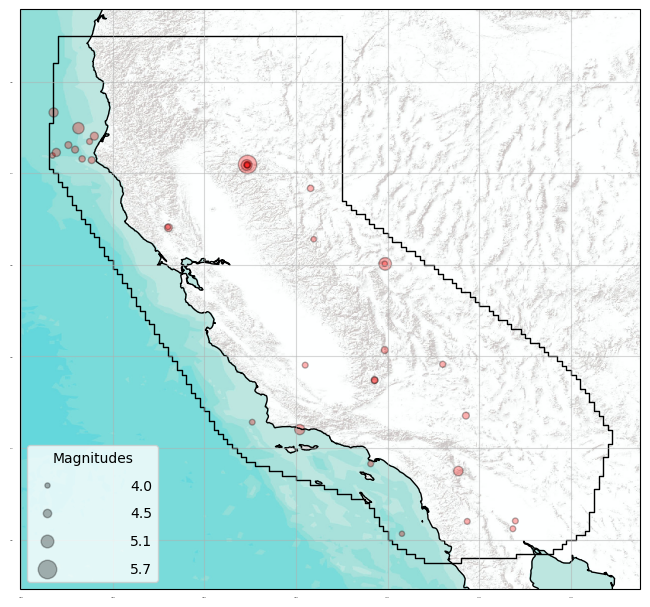

<GeoAxes: >

In [44]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2013-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2013-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [45]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [46]:
len(catalogEvents)

35

#### Q-Score

In [47]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

2
[4.500499883874909e-08, 4.821080210604123e-07]
[15, 2]
3.81461e-07
0.6909133706034796


In [62]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.0945928


#### L-Score

In [63]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-242.07106


### ETASV1.1

In [48]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [49]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

2
[1.795580040209188e-08, 8.736190011404688e-07]
[15, 2]
3.894178e-07
1.1447535099644044


In [92]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.8001409


#### L-Score

In [93]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-170.21208


### ETAS_DROneDayMd2

In [50]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [51]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

2
[4.7530002156292994e-09, 8.947999674546736e-08]
[15, 2]
1.2065554e-07
0.39050421990879325


In [77]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_DROneDayMd2
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.3288572


#### L-Score

In [78]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-165.19568


### ETAS_DROneDayMd3

In [52]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [53]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

2
[3.675999948882236e-09, 3.649000035466088e-08]
[15, 2]
1.7281195e-07
0.11621302801844652


In [74]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_DROneDayMd3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.402239


#### L-Score

In [75]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-161.70676


### ETAS_HWMd2

In [54]:
## Load ETAS_HWMd2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd2_filename = '../data/ETAS_HWMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd2 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [55]:
ETAS_HWMd2forecast = QL.combine_forecast_dataframes(ETAS_HWMd2)
del ETAS_HWMd2

QETAS_HWMd2 = QL.q_score_calc(
    forecast_df=ETAS_HWMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd2)

del ETAS_HWMd2forecast

2
[4.580000023679531e-08, 1.2700000695531344e-07]
[15, 2]
3.0029904e-07
0.2877132238414141


In [104]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd2

print(QL.calculate_Q_score(fore_df= ETAS_HWMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.725862


#### L-Score

In [105]:
print(QL.ell_score(fore_df= ETAS_HWMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd2_forec

-164.77116


### ETAS_HWMd3

In [56]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [57]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

2
[4.860000046846835e-08, 1.439999977037587e-07]
[15, 2]
3.0336568e-07
0.31743867256913255


In [89]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_HWMd3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.9237862


#### L-Score

In [90]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-164.83995


### STEPJAVA

In [58]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [59]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

2
[2.8016593489610386e-09, 5.5201646205482735e-12]
[15, 2]
2.1188156e-07
0.0066244074483970605


In [68]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del STEPJAVA
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.32946


#### L-Score

In [69]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf
-229.90321807193112


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


### KJSSOneDay

In [60]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [61]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

2
[8.306166865423847e-11, 1.6781989686798227e-10]
[15, 2]
2.8893076e-08
0.0043415516274282594


In [65]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.8443582


#### L-Score

In [66]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-197.21999


### K3Md2

In [64]:
## Load K3Md2 Model model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md2_filename = '../data/K3Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md2 = f_hdf5.load_hdf5_to_dict(K3Md2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013') 

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [65]:
K3Md2forecast = QL.combine_forecast_dataframes(K3Md2)
del K3Md2

QK3Md2= QL.q_score_calc(
    forecast_df=K3Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md2)

del K3Md2forecast

2
[5.5299999246472e-08, 2.1699999308566476e-07]
[15, 2]
3.028348e-07
0.44958505364403667


In [107]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md2

print(QL.calculate_Q_score(fore_df= K3Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.4439728


#### L-Score

In [108]:
print(QL.ell_score(fore_df= K3Md2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md2_forec

-195.63097


### K3Md3

In [66]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [67]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

2
[5.489999921337585e-08, 1.7099999638503505e-07]
[15, 2]
3.118894e-07
0.3621475905017053


In [71]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del K3Md3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.1440442


#### L-Score

In [72]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-202.26434


### ETAS_DROneDayPPEMd2

In [68]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [69]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

2
[2.3249999259178367e-08, 8.921999778976897e-07]
[15, 2]
4.1401046e-07
1.1055879865498688


In [83]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_DROneDayPPEMd2
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.0290474


#### L-Score

In [84]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-253.79436


### ETAS_DROneDayPPEMd3

In [70]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [71]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

2
[1.3820000255293508e-08, 1.6699999605407356e-07]
[15, 2]
2.9716892e-07
0.3042377274739659


In [80]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_DROneDayPPEMd3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.9752982


#### L-Score

In [81]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-237.91371


### ETAS_HW_K3_AVERAGE_Md2

In [72]:
## Load ETAS_HW_K3_AVERAGE_Md2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 1     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md2_filename = '../data/ETAS_HW_K3_AVERAGE_Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md2 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md2_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013') 

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [73]:
ETAS_HW_K3_AVERAGE_Md2forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md2)
del ETAS_HW_K3_AVERAGE_Md2

QETAS_HW_K3_AVERAGE_Md2= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md2)

del ETAS_HW_K3_AVERAGE_Md2forecast

2
[5.0549999741633656e-08, 1.720000000204891e-07]
[15, 2]
3.015677e-07
0.36898846139709174


In [101]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md2

print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6091936


#### L-Score

In [102]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                  cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md2_forec

-174.19962


### ETAS_HW_K3_AVERAGE_Md3

In [74]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [75]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

2
[5.17499998409221e-08, 1.5749999704439688e-07]
[15, 2]
3.0762706e-07
0.3401033637866656


In [86]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6847548


#### L-Score

In [87]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-176.58705


### OneDayBayesianBMA

In [76]:
## Load OneDayBayesianBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianBMA_filename = '../data/OneDayBayesianBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianBMA_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [77]:
OneDayBayesianBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianBMA)
del OneDayBayesianBMA

QOneDayBayesianBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianBMA)

del OneDayBayesianBMAforecast

2
[1.795580040209188e-08, 8.73228088948963e-07]
[15, 2]
3.8941175e-07
1.1442693798422738


In [95]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.8003397


#### L-Score

In [96]:
print(QL.ell_score(fore_df= OneDayBayesianBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianBMA_forec

-170.21939


### OneDayBayesianSeqBMA

In [78]:
## Load OneDayBayesianSeqBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianSeqBMA_filename = '../data/OneDayBayesianSeqBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianSeqBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianSeqBMA_filename,
                                     start_date = '01/01/2013', # format dd/mm/yyy
                                     end_date = '31/12/2013')

Loading year: 2013
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [79]:
OneDayBayesianSeqBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianSeqBMA)
del OneDayBayesianSeqBMA

QOneDayBayesianSeqBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianSeqBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianSeqBMA)

del OneDayBayesianSeqBMAforecast

2
[1.795580040209188e-08, 8.732981768844184e-07]
[15, 2]
3.894127e-07
1.1443566156707994


In [98]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianSeqBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianSeqBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianSeqBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianSeqBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.8003066


#### L-Score

In [99]:
print(QL.ell_score(fore_df= OneDayBayesianSeqBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianSeqBMA_forec

-170.21805


## 2014

Fetched ComCat catalog in 2.2162020206451416 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2014-01-01 15:47:16.460000+00:00
End Date: 2014-12-31 09:01:13.130000+00:00
Min Latitude: 31.5005 and Max Latitude: 42.6121667
Min Longitude: -125.3946667 and Max Longitude: -113.2118
Min Magnitude: 2.5
Found 1521 events in the ComCat catalog.

        Name: None

        Start Date: 2014-01-02 06:23:09.700000+00:00
        End Date: 2014-12-24 05:51:51.440000+00:00

        Latitude: (32.2121667, 41.9278)
        Longitude: (-125.3838333, -115.6085)

        Min Mw: 3.95
        Max Mw: 6.8

        Event Count: 44
        


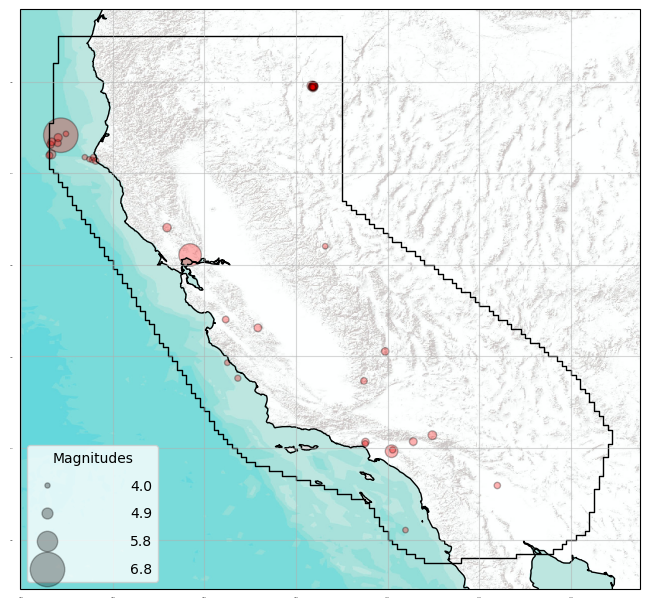

<GeoAxes: >

In [80]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2014-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2014-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [81]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [82]:
len(catalogEvents)

44

#### Q-Score

In [83]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

3
[2.9726100692073487e-08, 4.359090155503509e-08, 9.670629879110493e-07]
[6, 23, 16]
4.1964321e-07
0.8264004233897417


In [111]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.6192876


#### L-Score

In [112]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-281.8713


### ETASV1.1

In [84]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [85]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

3
[1.8512999133690755e-08, 1.6736699137709365e-08, 7.115460221029934e-07]
[6, 23, 16]
4.4887503e-07
0.5545684018191751


In [141]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6353881


#### L-Score

In [142]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-186.90817


### ETAS_DROneDayMd2

In [86]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [87]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

3
[8.811000262731739e-10, 2.4049999325370663e-08, 5.5670000165264355e-08]
[6, 23, 16]
2.303321e-07
0.11664476008224385


In [126]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.8716273


#### L-Score

In [127]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-177.07307


### ETAS_DROneDayMd3

In [88]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [89]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

3
[1.7190000534128558e-09, 5.216000076302407e-08, 8.706999921059833e-08]
[6, 23, 16]
3.2654316e-07
0.14387990913972432


In [123]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

5.055212


#### L-Score

In [124]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-180.12727


### ETAS_HWMd2

In [90]:
## Load ETAS_HWMd2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd2_filename = '../data/ETAS_HWMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd2 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [91]:
ETAS_HWMd2forecast = QL.combine_forecast_dataframes(ETAS_HWMd2)
del ETAS_HWMd2

QETAS_HWMd2 = QL.q_score_calc(
    forecast_df=ETAS_HWMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd2)

del ETAS_HWMd2forecast

3
[5.520000012637638e-09, 1.0499999802959792e-07, 2.310000013494573e-07]
[6, 23, 16]
3.6724595e-07
0.3099829995251516


In [153]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd2

print(QL.calculate_Q_score(fore_df= ETAS_HWMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.7055646


#### L-Score

In [154]:
print(QL.ell_score(fore_df= ETAS_HWMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd2_forec

-164.50772


### ETAS_HWMd3

In [92]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [93]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

3
[5.380000001053986e-09, 1.939999947353499e-07, 2.520000066397188e-07]
[6, 23, 16]
3.7094313e-07
0.405614741331218


In [138]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.81535846


#### L-Score

In [139]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-161.50389


### STEPJAVA

In [94]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [95]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

3
[0.0, 1.5144975407110906e-07, 3.735065376986313e-07]
[6, 23, 16]
2.315364e-07
0.7557577441891039


In [117]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del STEPJAVA

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

4.6815352


#### L-Score

In [118]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-278.74840067417153


### KJSSOneDay

In [96]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [97]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

3
[5.165156635733581e-10, 1.298609136890505e-10, 1.4706730944169522e-08]
[6, 23, 16]
3.626934e-08
0.1411027143745011


In [114]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.3453208


#### L-Score

In [115]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-207.66985


### K3Md2

In [98]:
## Load K3Md2 Model model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md2_filename = '../data/K3Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md2 = f_hdf5.load_hdf5_to_dict(K3Md2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014') 

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [99]:
K3Md2forecast = QL.combine_forecast_dataframes(K3Md2)
del K3Md2

QK3Md2= QL.q_score_calc(
    forecast_df=K3Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md2)

del K3Md2forecast

3
[8.119999783673393e-09, 1.310000019572044e-08, 2.5599999275982555e-07]
[6, 23, 16]
3.4093728e-07
0.27103713961422504


In [156]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md2

print(QL.calculate_Q_score(fore_df= K3Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.17458114


#### L-Score

In [157]:
print(QL.ell_score(fore_df= K3Md2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md2_forec

-184.08005


### K3Md3

In [100]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [101]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

3
[9.559999902819527e-09, 1.2200000121254106e-08, 4.849999868383748e-07]
[6, 23, 16]
3.573717e-07
0.47267311270487117


In [120]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.082921125


#### L-Score

In [121]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-193.63126


### ETAS_DROneDayPPEMd2

In [102]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [103]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

3
[8.078999691463196e-09, 1.318000020233967e-08, 5.324000085238367e-07]
[6, 23, 16]
4.1123783e-07
0.4487743761523803


In [132]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.58411396


#### L-Score

In [133]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-311.0488


### ETAS_DROneDayPPEMd3

In [104]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [105]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

3
[7.865000206663808e-09, 1.034999996818442e-08, 3.8860000017848506e-07]
[6, 23, 16]
2.9121333e-07
0.46565520278430217


In [129]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.73582864


#### L-Score

In [130]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-289.89304


### ETAS_HW_K3_AVERAGE_Md2

In [106]:
## Load ETAS_HW_K3_AVERAGE_Md2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 1     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md2_filename = '../data/ETAS_HW_K3_AVERAGE_Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md2 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md2_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014') 

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [107]:
ETAS_HW_K3_AVERAGE_Md2forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md2)
del ETAS_HW_K3_AVERAGE_Md2

QETAS_HW_K3_AVERAGE_Md2= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md2)

del ETAS_HW_K3_AVERAGE_Md2forecast

3
[6.82000012020012e-09, 5.904999866856997e-08, 2.4350001126549614e-07]
[6, 23, 16]
3.5402465e-07
0.2912885777938609


In [150]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md2

print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.425735


#### L-Score

In [151]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                  cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md2_forec

-169.71646


### ETAS_HW_K3_AVERAGE_Md3

In [108]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [109]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

3
[7.469999729892152e-09, 1.0309999964874805e-07, 3.6849999673904676e-07]
[6, 23, 16]
3.6445024e-07
0.43816680395953517


In [135]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.382392


#### L-Score

In [136]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-168.89622


### OneDayBayesianBMA

In [110]:
## Load OneDayBayesianBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianBMA_filename = '../data/OneDayBayesianBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianBMA_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [111]:
OneDayBayesianBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianBMA)
del OneDayBayesianBMA

QOneDayBayesianBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianBMA)

del OneDayBayesianBMAforecast

3
[1.8515862620915868e-08, 1.6744012398817176e-08, 7.116047981980955e-07]
[6, 23, 16]
4.4883933e-07
0.5546637167268338


In [144]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6337066


#### L-Score

In [145]:
print(QL.ell_score(fore_df= OneDayBayesianBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianBMA_forec

-186.91855


### OneDayBayesianSeqBMA

In [112]:
## Load OneDayBayesianSeqBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianSeqBMA_filename = '../data/OneDayBayesianSeqBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianSeqBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianSeqBMA_filename,
                                     start_date = '01/01/2014', # format dd/mm/yyy
                                     end_date = '31/12/2014')

Loading year: 2014
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [113]:
OneDayBayesianSeqBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianSeqBMA)
del OneDayBayesianSeqBMA

QOneDayBayesianSeqBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianSeqBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianSeqBMA)

del OneDayBayesianSeqBMAforecast

3
[1.851550379683431e-08, 1.6742852437801048e-08, 7.115894504750031e-07]
[6, 23, 16]
4.4884882e-07
0.554639460209207


In [147]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianSeqBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianSeqBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianSeqBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianSeqBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.6341755


#### L-Score

In [148]:
print(QL.ell_score(fore_df= OneDayBayesianSeqBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianSeqBMA_forec

-186.91606


## 2015

Fetched ComCat catalog in 1.7315058708190918 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2015-01-01 08:43:07.260000+00:00
End Date: 2015-12-31 17:59:26.740000+00:00
Min Latitude: 31.5081667 and Max Latitude: 42.5725
Min Longitude: -125.3966667 and Max Longitude: -113.1896667
Min Magnitude: 2.5
Found 1242 events in the ComCat catalog.

        Name: None

        Start Date: 2015-01-04 03:18:09.480000+00:00
        End Date: 2015-12-30 01:48:57.310000+00:00

        Latitude: (31.6135, 41.9006)
        Longitude: (-125.3966667, -115.2085)

        Min Mw: 3.98
        Max Mw: 5.72

        Event Count: 38
        


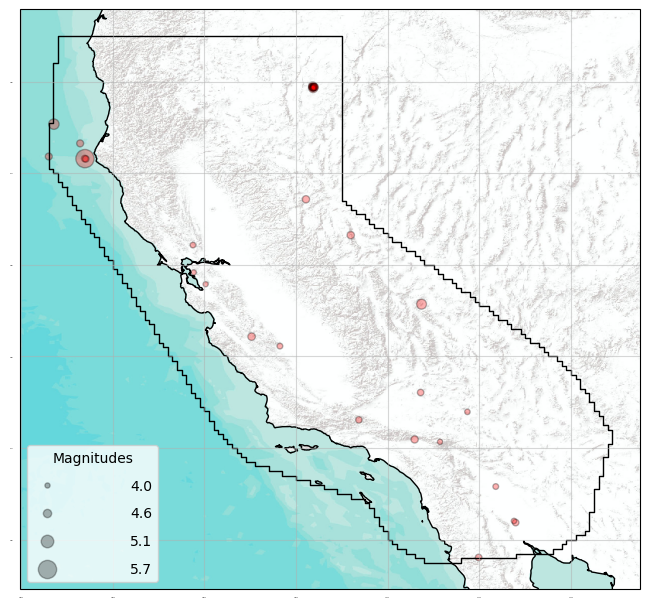

<GeoAxes: >

In [114]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2015-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2015-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [115]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [116]:
len(catalogEvents)

38

#### Q-Score

In [117]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

2
[4.1689500562824833e-07, 1.8082599808622035e-06]
[5, 36]
3.6166207e-07
3.076290193686324


In [160]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.754938


#### L-Score

In [161]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-246.74518


### ETASV1.1

In [118]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [119]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

2
[4.173450179223437e-06, 1.0016500482379342e-06]
[5, 36]
3.6912814e-07
7.009896560873489


In [190]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.87711674


#### L-Score

In [191]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-154.1322


### ETAS_DROneDayMd2

In [120]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [121]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

2
[1.8179999869971653e-06, 1.1809999733713994e-07]
[5, 36]
1.2315652e-07
7.860322401420664


In [175]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.8297951


#### L-Score

In [176]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-136.95143


### ETAS_DROneDayMd3

In [122]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [123]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

2
[2.705000042624306e-06, 2.7219999765293323e-07]
[5, 36]
1.7403731e-07
8.553338438890135


In [172]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.67174524


#### L-Score

In [173]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-137.0457


### ETAS_HWMd2

In [124]:
## Load ETAS_HWMd2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd2_filename = '../data/ETAS_HWMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd2 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [125]:
ETAS_HWMd2forecast = QL.combine_forecast_dataframes(ETAS_HWMd2)
del ETAS_HWMd2

QETAS_HWMd2 = QL.q_score_calc(
    forecast_df=ETAS_HWMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd2)

del ETAS_HWMd2forecast

2
[4.569999873638153e-06, 2.550000033352262e-07]
[5, 36]
3.0751323e-07
7.845190652941035


In [202]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd2

print(QL.calculate_Q_score(fore_df= ETAS_HWMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.20040658


#### L-Score

In [203]:
print(QL.ell_score(fore_df= ETAS_HWMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd2_forec

-139.4583


### ETAS_HWMd3

In [126]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [127]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

2
[7.990000085555948e-06, 3.0199998946045525e-07]
[5, 36]
3.1263409e-07
13.261509946422828


In [187]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.37064815


#### L-Score

In [188]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-134.88109


### STEPJAVA

In [128]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [129]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

2
[0.0, 0.0]
[5, 36]
1.8347033e-07
0.0


In [166]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del STEPJAVA

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.0


#### L-Score

In [167]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-212.33032553415916


### KJSSOneDay

In [130]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [131]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

2
[6.440846505029185e-07, 2.648984498421214e-08]
[5, 36]
2.5569824e-08
13.112614818780827


In [163]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.5082199


#### L-Score

In [164]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-181.4761


### K3Md2

In [132]:
## Load K3Md2 Model model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md2_filename = '../data/K3Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md2 = f_hdf5.load_hdf5_to_dict(K3Md2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015') 

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [133]:
K3Md2forecast = QL.combine_forecast_dataframes(K3Md2)
del K3Md2

QK3Md2= QL.q_score_calc(
    forecast_df=K3Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md2)

del K3Md2forecast

2
[3.6300000374467345e-06, 2.0999999605919584e-07]
[5, 36]
3.108495e-07
6.1766227693698585


In [205]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md2

print(QL.calculate_Q_score(fore_df= K3Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.08069553


#### L-Score

In [206]:
print(QL.ell_score(fore_df= K3Md2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md2_forec

-159.33887


### K3Md3

In [134]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [135]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

2
[1.8499999896448571e-06, 3.010000000358559e-07]
[5, 36]
3.3150437e-07
3.244301136519032


In [169]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.054896966


#### L-Score

In [170]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-161.37215


### ETAS_DROneDayPPEMd2

In [136]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [137]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

2
[1.1409999842726393e-06, 1.050000037139398e-06]
[5, 36]
4.0921967e-07
2.677046342870609


In [181]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.8456281


#### L-Score

In [182]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-253.15714


### ETAS_DROneDayPPEMd3

In [138]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [139]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

2
[1.3659999922310817e-06, 7.935000212455634e-07]
[5, 36]
2.8663413e-07
3.766997301548174


In [178]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.7088698


#### L-Score

In [179]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-232.92433


### ETAS_HW_K3_AVERAGE_Md2

In [140]:
## Load ETAS_HW_K3_AVERAGE_Md2 model
## start date: 01 Oct. 2012    end date: 19 Sep. 2016
## missing days: 1     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md2_filename = '../data/ETAS_HW_K3_AVERAGE_Md2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md2 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md2_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015') 

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [141]:
ETAS_HW_K3_AVERAGE_Md2forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md2)
del ETAS_HW_K3_AVERAGE_Md2

QETAS_HW_K3_AVERAGE_Md2= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md2)

del ETAS_HW_K3_AVERAGE_Md2forecast

2
[4.099999841855606e-06, 2.3249999969721102e-07]
[5, 36]
3.0918088e-07
7.006416262231307


In [199]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md2

print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.13933264


#### L-Score

In [200]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md2_forec,
                  cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md2_forec

-146.63353


### ETAS_HW_K3_AVERAGE_Md3

In [142]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [143]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

2
[4.919999810226727e-06, 3.014999947481556e-07]
[5, 36]
3.2206935e-07
8.106172995518456


In [184]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.20275785


#### L-Score

In [185]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-143.15112


### OneDayBayesianBMA

In [144]:
## Load OneDayBayesianBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianBMA_filename = '../data/OneDayBayesianBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianBMA_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [145]:
OneDayBayesianBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianBMA)
del OneDayBayesianBMA

QOneDayBayesianBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianBMA)

del OneDayBayesianBMAforecast

2
[4.173450179223437e-06, 1.0016500482379342e-06]
[5, 36]
3.6912814e-07
7.009896560873489


In [193]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.87711674


#### L-Score

In [194]:
print(QL.ell_score(fore_df= OneDayBayesianBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianBMA_forec

-154.1322


### OneDayBayesianSeqBMA

In [146]:
## Load OneDayBayesianSeqBMA model
## start date: 01 July 2012    end date: 07 Aug. 2016
## missing days: 0     min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
OneDayBayesianSeqBMA_filename = '../data/OneDayBayesianSeqBMA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
OneDayBayesianSeqBMA = f_hdf5.load_hdf5_to_dict(OneDayBayesianSeqBMA_filename,
                                     start_date = '01/01/2015', # format dd/mm/yyy
                                     end_date = '31/12/2015')

Loading year: 2015
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [147]:
OneDayBayesianSeqBMAforecast = QL.combine_forecast_dataframes(OneDayBayesianSeqBMA)
del OneDayBayesianSeqBMA

QOneDayBayesianSeqBMA= QL.q_score_calc(
    forecast_df=OneDayBayesianSeqBMAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QOneDayBayesianSeqBMA)

del OneDayBayesianSeqBMAforecast

2
[4.173450179223437e-06, 1.0016500482379342e-06]
[5, 36]
3.6912814e-07
7.009896560873489


In [196]:
all_df = []
#Loop through the nested dictionary
for year, months in OneDayBayesianSeqBMA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
OneDayBayesianSeqBMA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del OneDayBayesianSeqBMA

print(QL.calculate_Q_score(fore_df= OneDayBayesianSeqBMA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.87711674


#### L-Score

In [197]:
print(QL.ell_score(fore_df= OneDayBayesianSeqBMA_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del OneDayBayesianSeqBMA_forec

-154.1322


## 2016

Fetched ComCat catalog in 3.794299364089966 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2016-01-01 13:40:30.650000+00:00
End Date: 2016-12-31 23:48:13.270000+00:00
Min Latitude: 31.5016667 and Max Latitude: 42.444
Min Longitude: -125.3781667 and Max Longitude: -113.1156
Min Magnitude: 2.5
Found 1100 events in the ComCat catalog.

        Name: None

        Start Date: 2016-01-02 05:11:46.620000+00:00
        End Date: 2016-12-28 09:13:47.243000+00:00

        Latitude: (32.9583333, 41.8685)
        Longitude: (-125.3781667, -115.701)

        Min Mw: 3.95
        Max Mw: 5.6

        Event Count: 36
        


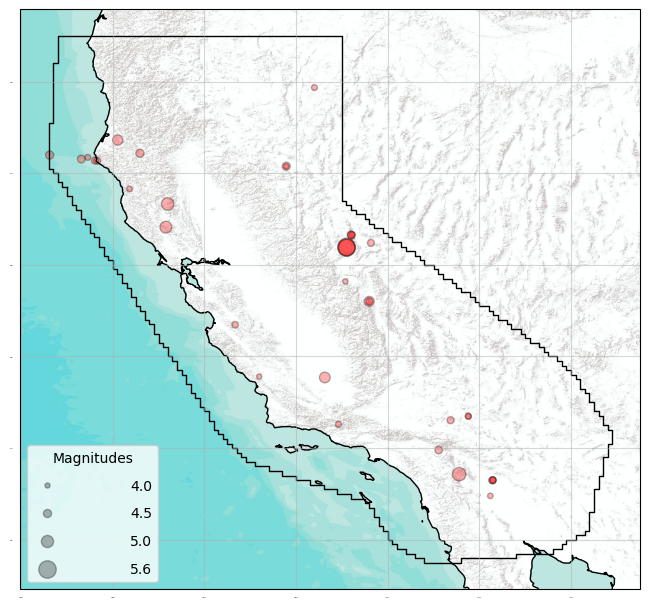

<GeoAxes: >

In [148]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2016-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2016-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [149]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95
#
# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [150]:
len(catalogEvents)

36

#### Q-Score

In [151]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

2
[1.3851300195710792e-07, 1.3851300195710792e-07]
[33, 34]
3.6600014e-07
0.378450683499146


In [209]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.4113102


#### L-Score

In [210]:
print(QL.ell_score(fore_df= ETAS_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-246.06372


### ETASV1.1

In [152]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [153]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

2
[9.184439875298267e-08, 9.184439875298267e-08]
[33, 34]
3.7315291e-07
0.2461307284835097


In [239]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.740312


#### L-Score

In [240]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-167.68134


### ETAS_DROneDayMd2

In [154]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [155]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

2
[1.0950000017828643e-08, 1.0950000017828643e-08]
[33, 34]
1.1722307e-07
0.09341164939555137


In [224]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.1549268


#### L-Score

In [225]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-158.01955


### ETAS_DROneDayMd3

In [156]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [157]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

2
[1.551999950777372e-08, 1.551999950777372e-08]
[33, 34]
1.5655442e-07
0.09913485298194405


In [221]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.7373854


#### L-Score

In [222]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-158.25244


### ETAS_HWMd3

In [158]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [159]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

2
[4.589999846871251e-08, 4.589999846871251e-08]
[33, 34]
3.0484793e-07
0.15056686941298913


In [236]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.9143507


#### L-Score

In [237]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-159.54663


### STEPJAVA

In [160]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [161]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

2
[7.602561247210815e-09, 7.602561247210815e-09]
[33, 34]
2.0237707e-07
0.03756631810783216


In [215]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del STEPJAVA

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.9024143


#### L-Score

In [216]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-184.96761668093234


### KJSSOneDay

In [162]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [163]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

2
[6.097513161051893e-09, 6.097513161051893e-09]
[33, 34]
2.8040233e-08
0.2174558644881601


In [212]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.5418363


#### L-Score

In [213]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-224.14252


### K3Md3

In [164]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [165]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

2
[7.340000252042955e-08, 7.340000252042955e-08]
[33, 34]
2.968885e-07
0.247230881973533


In [218]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))


0.65831786


#### L-Score

In [219]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-206.37994


### ETAS_DROneDayPPEMd2

In [166]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [167]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

2
[1.0419999796340562e-07, 1.0419999796340562e-07]
[33, 34]
4.0721045e-07
0.25588733761583715


In [230]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.23653539


#### L-Score

In [231]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-248.94925


### ETAS_DROneDayPPEMd3

In [168]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [169]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

2
[6.986999778746394e-08, 6.986999778746394e-08]
[33, 34]
2.819327e-07
0.247825094194589


In [227]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.15363483


#### L-Score

In [228]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-234.2545


### ETAS_HW_K3_AVERAGE_Md3

In [170]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2016', # format dd/mm/yyy
                                     end_date = '31/12/2016')

Loading year: 2016
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [171]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

2
[5.964999871821419e-08, 5.964999871821419e-08]
[33, 34]
3.0102692e-07
0.1981550342101638


In [233]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.5636597


#### L-Score

In [234]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-172.85724


## 2017

Fetched ComCat catalog in 2.1213440895080566 seconds.

Downloaded catalog from ComCat with following parameters
Start Date: 2017-01-01 00:04:56.020000+00:00
End Date: 2017-12-31 19:49:06.270000+00:00
Min Latitude: 31.5071667 and Max Latitude: 42.1398333
Min Longitude: -125.3621667 and Max Longitude: -113.1378333
Min Magnitude: 2.5
Found 961 events in the ComCat catalog.

        Name: None

        Start Date: 2017-02-21 00:57:52.710000+00:00
        End Date: 2017-12-14 04:57:18.580000+00:00

        Latitude: (32.225, 41.0753333)
        Longitude: (-125.3303333, -115.2278333)

        Min Mw: 3.95
        Max Mw: 5.08

        Event Count: 18
        


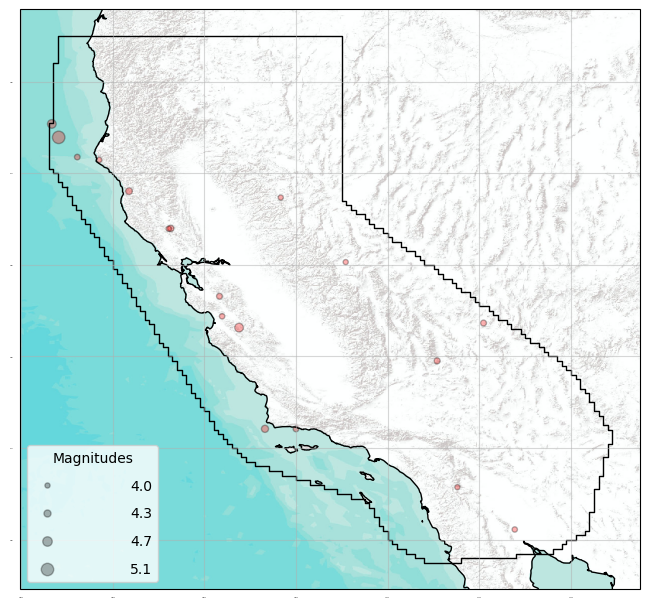

<GeoAxes: >

In [172]:
# set start and end date
start_time = csep.utils.time_utils.strptime_to_utc_datetime('2017-01-01 00:00:00.0')
end_time = csep.utils.time_utils.strptime_to_utc_datetime('2017-12-31 23:59:59.0')
# retrieve events in ComCat catalogue between start and end date
catalog = csep.query_comcat(start_time, end_time)

# set magnitude limits
min_mw = 3.95
max_mw = 8.95
# set magnitude bin length
dmw = 0.1

# Create space and magnitude regions. The forecast is already filtered in space and magnitude
magnitudes = csep.regions.magnitude_bins(min_mw, max_mw, dmw)
region = csep.regions.california_relm_region()

# Bind region information to the forecast
space_magnitude_region = csep.regions.create_space_magnitude_region(region, magnitudes)


# filter magnitude below 3.95
catalog.filter('magnitude >= 3.95')
# filter events outside spatial region
catalog.filter_spatial(space_magnitude_region)
# print summary information
print(catalog)

# Convert catalog of events into a directory
catalogEvents = QL.catalog_to_direct(catalog)
catalog.plot(show=True)

### ETAS

In [173]:
## Load ETAS model
## start date: 01 Aug. 2007    end date: 30 Aug. 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
etas_filename = '../data/ETAS_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS = f_hdf5.load_hdf5_to_dict(etas_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


In [174]:
len(catalogEvents)

18

#### Q-Score

In [175]:
ETASforecast = QL.combine_forecast_dataframes(ETAS)
del ETAS

QETAS = QL.q_score_calc(
    forecast_df=ETASforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS)

del ETASforecast

1
[1.8018199625657871e-06]
[9]
3.2066475e-07
5.619014697952242


In [243]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in ETAS.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del ETAS
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.5255775


#### L-Score

In [244]:
print(QL.ell_score(fore_df= ETAS_forec,
                    cat_df = catalogEvents))

#Optional to free memory space
del ETAS_forec

-147.35815


### ETASV1.1

In [176]:
## Load ETASV1.1 model
## start date: 01 July 2012    end date: 30 June 2018
## missing days: 4      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASV1_1_filename = '../data/ETASV1_1_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASV1_1 = f_hdf5.load_hdf5_to_dict(ETASV1_1_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [177]:
ETASV1_1forecast = QL.combine_forecast_dataframes(ETASV1_1)
del ETASV1_1

QETASV1_1 = QL.q_score_calc(
    forecast_df=ETASV1_1forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASV1_1)

del ETASV1_1forecast

1
[4.079509835719364e-06]
[9]
3.2922514e-07
12.391246229576694


In [285]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASV1_1.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASV1_1_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASV1_1

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASV1_1_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

2.2102718


#### L-Score

In [286]:
print(QL.ell_score(fore_df= ETASV1_1_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASV1_1_forec

-113.57508


### ETAS_DROneDayMd2

In [178]:
## Load ETAS_DROneDayMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 17       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_filename = '../data/ETAS_DROneDayMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [179]:
ETAS_DROneDayMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2)
del ETAS_DROneDayMd2

QETAS_DROneDayMd2 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2)

del ETAS_DROneDayMd2forecast

1
[1.4309999869510648e-06]
[9]
9.814066e-08
14.581112316980727


In [267]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.8233087


#### L-Score

In [268]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_forec

-101.22794


### ETAS_DROneDayMd3

In [180]:
## Load ETAS_DROneDayMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd3_filename = '../data/ETAS_DROneDayMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [181]:
ETAS_DROneDayMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd3)
del ETAS_DROneDayMd3

QETAS_DROneDayMd3 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd3)

del ETAS_DROneDayMd3forecast

1
[3.8079999740148196e-06]
[9]
1.4756455e-07
25.805655892199603


In [261]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.2654457


#### L-Score

In [262]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd3_forec

-100.63479


### ETAS_DROneDayMd2.95

In [182]:
## Load ETAS_DROneDayMd2_95 model
## start date: 01 July 2016    end date: 30 June 2018
## missing days: 18       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayMd2_95_filename = '../data/ETAS_DROneDayMd2.95_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayMd2_95 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayMd2_95_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [183]:
ETAS_DROneDayMd2_95forecast = QL.combine_forecast_dataframes(ETAS_DROneDayMd2_95)
del ETAS_DROneDayMd2_95

QETAS_DROneDayMd2_95 = QL.q_score_calc(
    forecast_df=ETAS_DROneDayMd2_95forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayMd2_95)

del ETAS_DROneDayMd2_95forecast

1
[3.808999963439419e-06]
[9]
1.4499204e-07
26.270406829111856


In [264]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayMd2_95.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayMd2_95_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayMd2_95

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayMd2_95_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.3383002


#### L-Score

In [265]:
print(QL.ell_score(fore_df= ETAS_DROneDayMd2_95_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayMd2_95_forec

-99.53112


### ETASSYN_DROneDayMd2.95

In [184]:
## Load ETASSYN_DROneDayMd2.95 model
## start date: 01 July 2016    end date: 30 June 2018
## missing days: 11      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETASSYN_DROneDayMd2_95_filename = '../data/ETASSYN_DROneDayMd2.95_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETASSYN_DROneDayMd2_95 = f_hdf5.load_hdf5_to_dict(ETASSYN_DROneDayMd2_95_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [185]:
ETASSYN_DROneDayMd2_95forecast = QL.combine_forecast_dataframes(ETASSYN_DROneDayMd2_95)
del ETASSYN_DROneDayMd2_95

QETASSYN_DROneDayMd2_95 = QL.q_score_calc(
    forecast_df=ETASSYN_DROneDayMd2_95forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETASSYN_DROneDayMd2_95)

del ETASSYN_DROneDayMd2_95forecast

1
[1.1940000149479602e-05]
[9]
3.0824577e-07
38.73532474587923


In [276]:
all_df = []
#Loop through the nested dictionary
for year, months in ETASSYN_DROneDayMd2_95.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETASSYN_DROneDayMd2_95_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETASSYN_DROneDayMd2_95

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETASSYN_DROneDayMd2_95_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

3.942039


#### L-Score

In [277]:
print(QL.ell_score(fore_df= ETASSYN_DROneDayMd2_95_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETASSYN_DROneDayMd2_95_forec

-99.93555


### ETAS_HWMd3

In [186]:
## Load ETAS_HWMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HWMd3_filename = '../data/ETAS_HWMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HWMd3 = f_hdf5.load_hdf5_to_dict(ETAS_HWMd3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [187]:
ETAS_HWMd3forecast = QL.combine_forecast_dataframes(ETAS_HWMd3)
del ETAS_HWMd3

QETAS_HWMd3 = QL.q_score_calc(
    forecast_df=ETAS_HWMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HWMd3)

del ETAS_HWMd3forecast

1
[8.200000252145401e-07]
[9]
2.8021898e-07
2.9262829143849443


In [282]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HWMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HWMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HWMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HWMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.6154245


#### L-Score

In [283]:
print(QL.ell_score(fore_df= ETAS_HWMd3_forec,
                     cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HWMd3_forec

-105.5217


### GSF_ISO

In [188]:
## Load GSF_ISO model
## start date: 01 Oct. 2016    end date: 30 June 2018
## missing days: 1        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ISO_filename = '../data/GSF_ISO_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ISO = f_hdf5.load_hdf5_to_dict(ISO_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [189]:
ISOforecast = QL.combine_forecast_dataframes(ISO)
del ISO

QISO = QL.q_score_calc(
    forecast_df=ISOforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QISO)

del ISOforecast

1
[1.5606777878929279e-06]
[9]
3.5680313e-07
4.374058598869801


In [252]:
all_df = []
#Loop through the nested dictionary
for year, months in ISO.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ISO_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ISO

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ISO_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.9367224


#### L-Score

In [253]:
print(QL.ell_score(fore_df= ISO_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ISO_forec

-144.61604


### GSF_ANISO

In [190]:
## Load GSF_ANISO model
## start date: 01 Oct. 2016    end date: 30 June 2018
## missing days: 1        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ANISO_filename = '../data/GSF_ANISO_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ANISO = f_hdf5.load_hdf5_to_dict(ANISO_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [191]:
ANISOforecast = QL.combine_forecast_dataframes(ANISO)
del ANISO

QANISO = QL.q_score_calc(
    forecast_df=ANISOforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QANISO)

del ANISOforecast

1
[1.0947347917067418e-08]
[9]
3.412684e-07
0.03207841174970522


In [255]:
all_df = []
#Loop through the nested dictionary
for year, months in ANISO.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ANISO_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ANISO

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ANISO_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.7680183


#### L-Score

In [256]:
print(QL.ell_score(fore_df= ANISO_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ANISO_forec

-134.8453


### STEPJAVA

In [192]:
## Load STEPJAVA model
## start date: 01 Sep. 2010    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
STEPJAVA_filename = '../data/STEPJAVA_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
STEPJAVA = f_hdf5.load_hdf5_to_dict(STEPJAVA_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [193]:
STEPJAVAforecast = QL.combine_forecast_dataframes(STEPJAVA)
del STEPJAVA

QSTEPJAVA = QL.q_score_calc(
    forecast_df=STEPJAVAforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QSTEPJAVA)

del STEPJAVAforecast

1
[0.0]
[9]
1.8008126e-07
0.0


In [249]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in STEPJAVA.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
STEPJAVA_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del STEPJAVA

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= STEPJAVA_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.0


#### L-Score

In [250]:
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents))

# add waterlevelto zero valued bins
print(QL.ell_score(fore_df= STEPJAVA_forec,
                 cat_df = catalogEvents,
                 waterlevel = 1e-6))

#Optional to free memory space
del STEPJAVA_forec

C:\Users\arjon\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


-inf


C:\Users\arjon\OneDrive\Documents\S Score\Project\src\QandL.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_out.iloc[target_idx,6] = waterlevel


-133.11524686813593


### KJSSOneDay

In [194]:
## Load KJSSOneDay model
## start date: 01 Jan. 2009    end date: 30 June 2018
## missing days: 0        min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
KJSSOne_filename = '../data/KJSSOneDayCalifornia_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
KJSSOne = f_hdf5.load_hdf5_to_dict(KJSSOne_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [195]:
KJSSOneforecast = QL.combine_forecast_dataframes(KJSSOne)
del KJSSOne

QKJSSOne = QL.q_score_calc(
    forecast_df=KJSSOneforecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QKJSSOne)

del KJSSOneforecast

1
[1.8666459311589279e-07]
[9]
1.755911e-08
10.630641078817186


In [246]:
#Initialize an empty list to store data
all_df = []
#Loop through the nested dictionary
for year, months in KJSSOne.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
KJSSOne_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del KJSSOne
del all_df

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= KJSSOne_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.37769166


#### L-Score

In [247]:
print(QL.ell_score(fore_df= KJSSOne_forec,
                        cat_df = catalogEvents))

#Optional to free memory space
del KJSSOne_forec

-112.88315


### K3Md3

In [196]:
## Load K3Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 5       min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
K3Md3_filename = '../data/K3Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
K3Md3 = f_hdf5.load_hdf5_to_dict(K3Md3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [197]:
K3Md3forecast = QL.combine_forecast_dataframes(K3Md3)
del K3Md3

QK3Md3= QL.q_score_calc(
    forecast_df=K3Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QK3Md3)

del K3Md3forecast

1
[5.53999996100174e-07]
[9]
3.0285366e-07
1.8292662829977826


In [258]:
all_df = []
#Loop through the nested dictionary
for year, months in K3Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
K3Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del K3Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= K3Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.1325039


#### L-Score

In [259]:
print(QL.ell_score(fore_df= K3Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del K3Md3_forec

-134.32376


### ETAS_DROneDayPPEMd2

In [198]:
## Load ETAS_DROneDayPPEMd2 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 18      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd2_filename = '../data/ETAS_DROneDayPPEMd2_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd2 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd2_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [199]:
ETAS_DROneDayPPEMd2forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd2)
del ETAS_DROneDayPPEMd2

QETAS_DROneDayPPEMd2= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd2forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd2)

del ETAS_DROneDayPPEMd2forecast

1
[9.423999927093973e-07]
[9]
4.0469e-07
2.32869594579979


In [273]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd2.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd2_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd2

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

0.6988856


#### L-Score

In [274]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd2_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd2_forec

-151.1072


### ETAS_DROneDayPPEMd3

In [200]:
## Load ETAS_DROneDayPPEMd3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 6      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_DROneDayPPEMd3_filename = '../data/ETAS_DROneDayPPEMd3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_DROneDayPPEMd3 = f_hdf5.load_hdf5_to_dict(ETAS_DROneDayPPEMd3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [201]:
ETAS_DROneDayPPEMd3forecast = QL.combine_forecast_dataframes(ETAS_DROneDayPPEMd3)
del ETAS_DROneDayPPEMd3

QETAS_DROneDayPPEMd3= QL.q_score_calc(
    forecast_df=ETAS_DROneDayPPEMd3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_DROneDayPPEMd3)

del ETAS_DROneDayPPEMd3forecast

1
[1.2030000107188243e-06]
[9]
2.778304e-07
4.329979843049125


In [270]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_DROneDayPPEMd3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_DROneDayPPEMd3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_DROneDayPPEMd3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.1019335


#### L-Score

In [271]:
print(QL.ell_score(fore_df= ETAS_DROneDayPPEMd3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_DROneDayPPEMd3_forec

-140.43784


### ETAS_HW_K3_AVERAGE_Md3

In [202]:
## Load ETAS_HW_K3_AVERAGE_Md3 model
## start date: 01 Oct. 2012    end date: 30 June 2018
## missing days: 23      min. magnitude: 3.95

# model path within the quatation marks **Depends on dowloading the forecast files and stored them in the data folder**
# file name is assumed to not have been renamed from download
ETAS_HW_K3_AVERAGE_Md3_filename = '../data/ETAS_HW_K3_AVERAGE_Md3_1day.hdf5'
# this will be a dictonary of pandas.DataFrames
ETAS_HW_K3_AVERAGE_Md3 = f_hdf5.load_hdf5_to_dict(ETAS_HW_K3_AVERAGE_Md3_filename,
                                     start_date = '01/01/2017', # format dd/mm/yyy
                                     end_date = '31/12/2017')

Loading year: 2017
Loading month: 1
Loading month: 10
Loading month: 11
Loading month: 12
Loading month: 2
Loading month: 3
Loading month: 4
Loading month: 5
Loading month: 6
Loading month: 7
Loading month: 8
Loading month: 9


#### Q-Score

In [203]:
ETAS_HW_K3_AVERAGE_Md3forecast = QL.combine_forecast_dataframes(ETAS_HW_K3_AVERAGE_Md3)
del ETAS_HW_K3_AVERAGE_Md3

QETAS_HW_K3_AVERAGE_Md3= QL.q_score_calc(
    forecast_df=ETAS_HW_K3_AVERAGE_Md3forecast, 
    events=catalogEvents, 
    alpha=0.05
)

print(QETAS_HW_K3_AVERAGE_Md3)

del ETAS_HW_K3_AVERAGE_Md3forecast

1
[6.87000010657357e-07]
[9]
2.9153685e-07
2.3564774442529646


In [279]:
all_df = []
#Loop through the nested dictionary
for year, months in ETAS_HW_K3_AVERAGE_Md3.items():
    for month, files in months.items():
        for file_, df in files.items():
            #Append the dataframe to the list
            all_df.append(df)
            
#combine all the dataframes in the files into a single dataframe
ETAS_HW_K3_AVERAGE_Md3_forec = pd.concat(all_df, ignore_index = True)

#Optional to free memory space
del all_df
del ETAS_HW_K3_AVERAGE_Md3

#Q Score Calculation with different percentage retention
print(QL.calculate_Q_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                                cat_df = catalogEvents,
                                perc_retain = 0.05))

1.0725383


#### L-Score

In [280]:
print(QL.ell_score(fore_df= ETAS_HW_K3_AVERAGE_Md3_forec,
                    cat_df = catalogEvents))
#Optional to free memory space
del ETAS_HW_K3_AVERAGE_Md3_forec

-113.54112
